In [12]:
from pathlib import Path
import subprocess

import openeo
import contextily
import shapely
import pystac
import pystac_client
import matplotlib.pyplot as plt
import rioxarray

import notebook_utils as utils

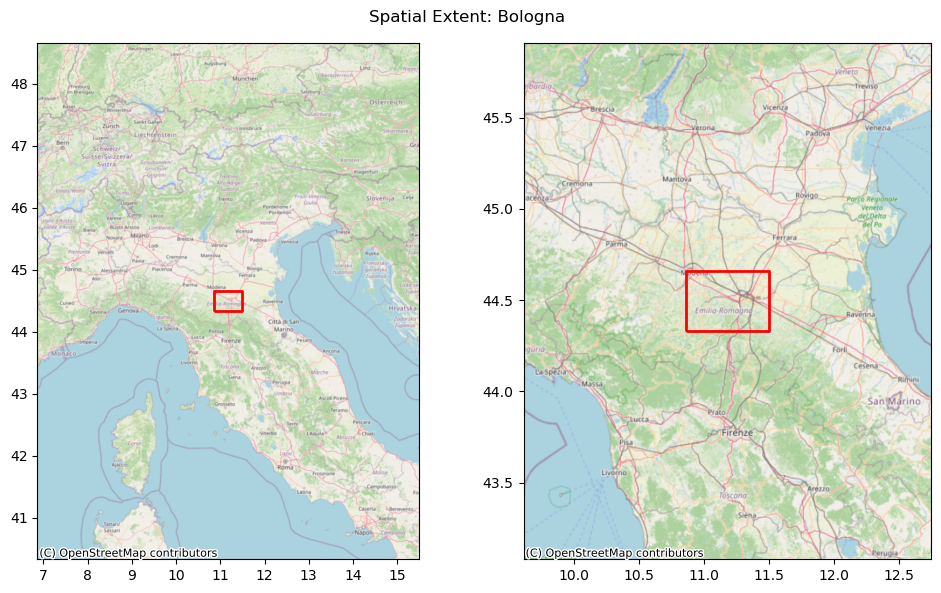

In [2]:
w,s,e,n = 10.864, 44.330, 11.497, 44.659 # This fails currently
spatial_extent = { "west": w, "south": s, "east": e, "north": n}
aoi_name = "Bologna"
#temporal_extent=["2026-03-01", "2026-03-31"]
temporal_extent=["2026-03-01", "2026-03-10"]

utils.plot_area_of_interest(
    w=w,
    s=s,
    e=e,
    n=n,
    large_context=4,
    figsize=(10, 6),
    title=f"Spatial Extent: {aoi_name}"
)

In [3]:
backend_url = "openeo-staging.dataspace.copernicus.eu"
connection = openeo.connect(backend_url).authenticate_oidc()

Authenticated using refresh token.


In [13]:
L1C_COLLECTION_URL = "https://stac.dataspace.copernicus.eu/v1/collections/sentinel-2-l1c"

client = pystac_client.Client.open("https://stac.dataspace.copernicus.eu/v1")
search = client.search(
    datetime=temporal_extent,
    collections=["sentinel-2-l1c"],
    bbox=[w, s, e, n]
)
item_collection = search.item_collection()

print("Found items:")
for item in search.items():
    print(item.id)


Found items:
S2A_MSIL1C_20260310T101051_N0512_R022_T32TPQ_20260310T152637
S2C_MSIL1C_20260308T100851_N0512_R022_T32TPQ_20260308T142021
S2B_MSIL1C_20260303T101019_N0512_R022_T32TPQ_20260303T152416


In [14]:
# This is currently necessary to pass a longer list of inputs to FORCE level 2
catalog = utils.transform_item_collection_to_catalog_with_links(item_collection)
catalog

<Catalog id=item-collection-catalog>

In [15]:
cwl_root = Path("../cwl").resolve()
level2_res = subprocess.run(
    [
        "cwltool",
        "--pack",
        str(cwl_root / "force-l2-workflow.cwl"),
    ],
    capture_output=True
)
try:
    level2_res.check_returncode()
except subprocess.CalledProcessError as e:
    print("STDERR")
    print(level2_res.stderr.decode())
    raise e
cwl_level2 = level2_res.stdout.decode()

In [17]:
context = dict(
    stac_document=catalog.to_dict(),
)

stac_resource = openeo.rest.stac_resource.StacResource(
    graph=openeo.internal.graph_building.PGNode(
        process_id="run_cwl_to_stac",
        arguments={
            "cwl": cwl_level2,
            "context": context,
        }
    ),
    connection=connection,
)
l2_job = stac_resource.create_job(title=f"FORCE level 2 - {aoi_name} - debug")
print(f"Job id: '{l2_job.job_id}'")
l2_job.start_and_wait()

Job id: 'j-2604230712144de088c7bf8a4683020b'
0:00:00 Job 'j-2604230712144de088c7bf8a4683020b': send 'start'
0:00:14 Job 'j-2604230712144de088c7bf8a4683020b': created (progress 0%)
0:00:19 Job 'j-2604230712144de088c7bf8a4683020b': created (progress 0%)
0:00:26 Job 'j-2604230712144de088c7bf8a4683020b': created (progress 0%)
0:00:34 Job 'j-2604230712144de088c7bf8a4683020b': created (progress 0%)
0:00:44 Job 'j-2604230712144de088c7bf8a4683020b': created (progress 0%)
0:00:56 Job 'j-2604230712144de088c7bf8a4683020b': running (progress 8.2%)
0:01:12 Job 'j-2604230712144de088c7bf8a4683020b': running (progress 10.3%)
0:01:31 Job 'j-2604230712144de088c7bf8a4683020b': running (progress 12.8%)
0:01:55 Job 'j-2604230712144de088c7bf8a4683020b': running (progress 15.8%)
0:02:26 Job 'j-2604230712144de088c7bf8a4683020b': running (progress 19.2%)
0:03:03 Job 'j-2604230712144de088c7bf8a4683020b': running (progress 23.1%)
0:03:50 Job 'j-2604230712144de088c7bf8a4683020b': running (progress 27.4%)
0:04:48 

JobFailedException: Batch job 'j-2604230712144de088c7bf8a4683020b' didn't finish successfully. Status: error (after 0:06:49).